In [11]:
pip install xgboost shap scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
df = pd.read_csv("prematch_features.csv")
print(df["date"].dtype)
print(df["date"].head(10))

object
0    2008-04-18
1    2008-04-19
2    2008-04-19
3    2008-04-20
4    2008-04-20
5    2008-04-21
6    2008-04-22
7    2008-04-23
8    2008-04-24
9    2008-04-25
Name: date, dtype: object


In [13]:
import pandas as pd

# Load both files
prematch = pd.read_csv("prematch_features.csv")
matches  = pd.read_csv("matches.csv")

# Normalize match id column name
if "id" not in matches.columns and "match_id" in matches.columns:
    matches = matches.rename(columns={"match_id": "id"})

# Parse date from matches.csv and merge it in by match id
matches["date"] = pd.to_datetime(matches["date"], dayfirst=True, errors="coerce")

# Drop the broken date column and re-merge
prematch = prematch.drop(columns=["date"], errors="ignore")
prematch = prematch.merge(matches[["id", "date"]], on="id", how="left")

print(prematch["date"].dtype)
print(prematch["date"].head())
print(f"Nulls in date: {prematch['date'].isna().sum()}")

# Save fixed CSV
prematch.to_csv("prematch_features.csv", index=False)
print("Done — prematch_features.csv updated")

datetime64[ns]
0   2008-04-18
1   2008-04-19
2   2008-04-19
3   2008-04-20
4   2008-04-20
Name: date, dtype: datetime64[ns]
Nulls in date: 0
Done — prematch_features.csv updated


IPL Pre-Match Win Predictor — XGBoost

Step 1 — Loading data and splitting by season
  Date range: 2008-04-18 → 2024-05-26
  Total rows: 1076
  Seasons found: [np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]
Train: 932 matches (2008–2022)
Test : 144 matches (2023–2024)
Target balance (train): 0.508 team1 win rate

Step 2 — Training XGBoost

CV Accuracy: 0.4580 ± 0.0656
CV per fold: [np.float64(0.5241), np.float64(0.5134), np.float64(0.4086), np.float64(0.3548), np.float64(0.4892)]

Model trained — 300 trees, max_depth=4

Step 3 — Evaluating on test set

── Test Set Results ──
Accuracy : 0.4514
Log-Loss : 0.7845

Classification Report:
              precision    recall  f1-score   support

  Team2 wins       0.45      0.71      0.55        69
  Team1 wins       0.44 

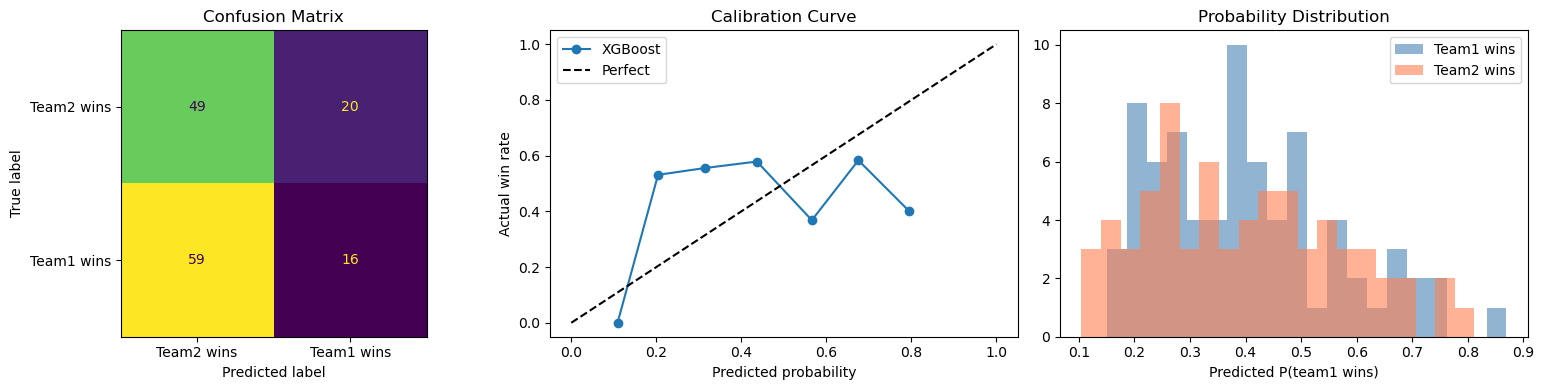

Saved → prematch_evaluation.png

Step 4 — SHAP explainability


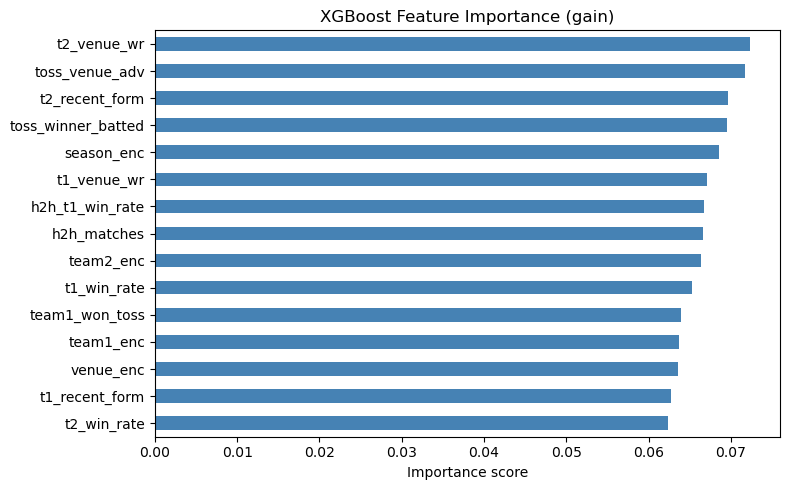

Saved → prematch_feature_importance.png


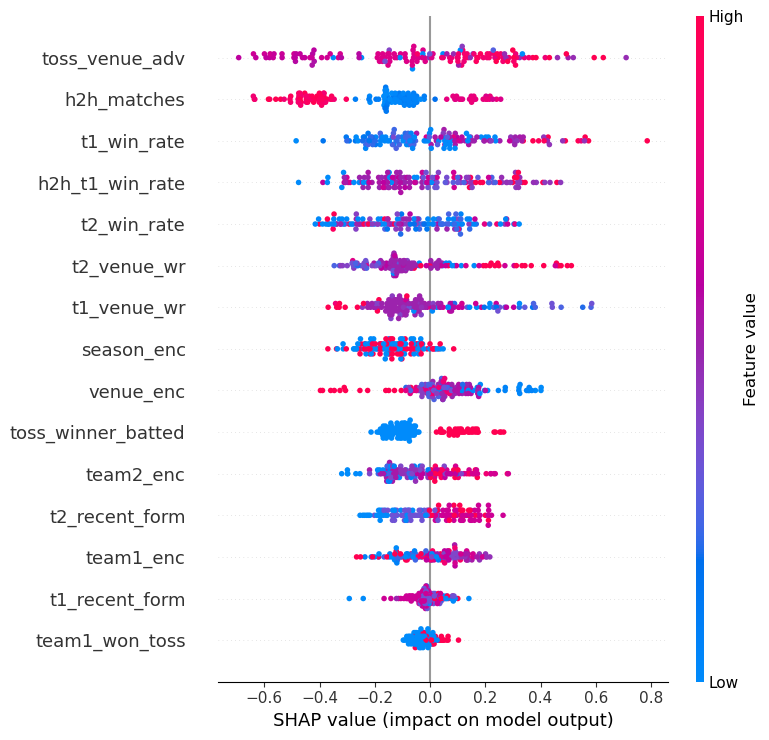

Saved → prematch_shap_summary.png


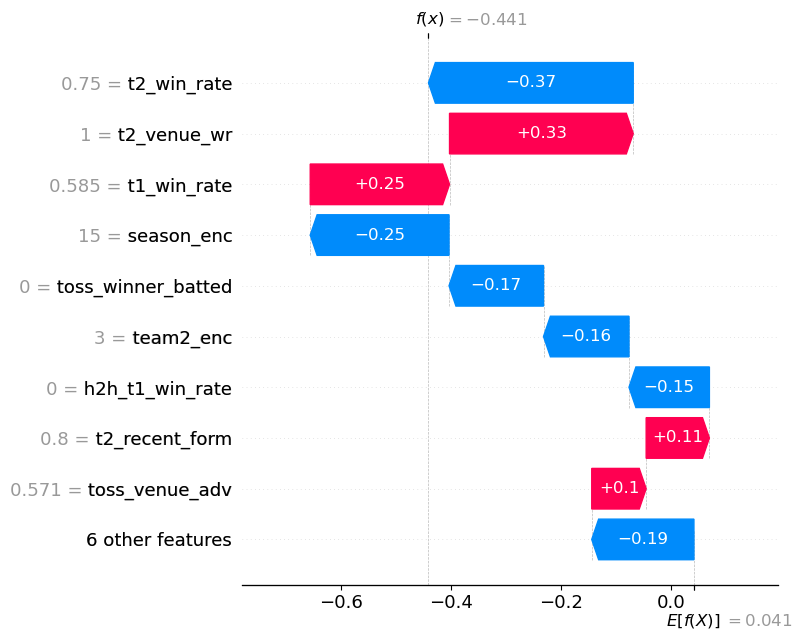

Saved → prematch_shap_waterfall.png

Step 5 — Saving model
Saved → prematch_model.pkl

✓ Done!
  Test accuracy : 0.4514
  Test log-loss : 0.7845
  Artifacts saved: prematch_model.pkl, prematch_evaluation.png,
                   prematch_feature_importance.png, prematch_shap_summary.png


In [14]:
"""
IPL Win Predictor — Pre-Match XGBoost Model
============================================
Input:  prematch_features.csv  (output of ipl_feature_engineering.py)
Output: prematch_model.pkl     (trained XGBoost model + encoders)

Sections:
  1. Load & split (time-based — no leakage)
  2. Train XGBoost with cross-validation
  3. Evaluate (accuracy, log-loss, calibration)
  4. SHAP explainability
  5. Save model
  6. Predict function (used by Streamlit app)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, log_loss,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
import shap


# ─────────────────────────────────────────────
# 1. LOAD & TIME-BASED TRAIN/TEST SPLIT
# ─────────────────────────────────────────────

FEATURES = [
    "team1_enc", "team2_enc", "venue_enc", "season_enc",
    "team1_won_toss", "toss_winner_batted",
    "t1_win_rate", "t2_win_rate",
    "h2h_t1_win_rate", "h2h_matches",
    "t1_venue_wr", "t2_venue_wr",
    "toss_venue_adv",
    "t1_recent_form", "t2_recent_form",
]
TARGET = "team1_won"

def load_and_split(path="prematch_features.csv", test_seasons=2):
    df = pd.read_csv(path)

    # Robust date parsing — handles any format in the CSV
    df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
    n_bad = df["date"].isna().sum()
    if n_bad > 0:
        print(f"  Warning: {n_bad} rows had unparseable dates and were dropped")
    df = df.dropna(subset=["date"])
    df = df.sort_values("date").reset_index(drop=True)

    print(f"  Date range: {df['date'].min().date()} → {df['date'].max().date()}")
    print(f"  Total rows: {len(df)}")

    # Time-based split: last `test_seasons` IPL seasons as test set
    # Never use random split — that leaks future match history into training
    seasons = sorted(df["date"].dt.year.unique())
    print(f"  Seasons found: {seasons}")

    if len(seasons) < test_seasons + 1:
        raise ValueError(f"Not enough seasons ({len(seasons)}) to hold out {test_seasons}. Reduce test_seasons.")

    cutoff_year = seasons[-test_seasons]

    train = df[df["date"].dt.year < cutoff_year]
    test  = df[df["date"].dt.year >= cutoff_year]

    X_train = train[FEATURES]
    y_train = train[TARGET]
    X_test  = test[FEATURES]
    y_test  = test[TARGET]

    print(f"Train: {len(train)} matches ({seasons[0]}–{cutoff_year-1})")
    print(f"Test : {len(test)} matches ({cutoff_year}–{seasons[-1]})")
    print(f"Target balance (train): {y_train.mean():.3f} team1 win rate")

    return X_train, y_train, X_test, y_test, train, test


# ─────────────────────────────────────────────
# 2. TRAIN XGBOOST
# ─────────────────────────────────────────────

def train_model(X_train, y_train):
    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,               # shallow trees — avoids overfitting on ~700 rows
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,        # prevents splits on very small groups
        gamma=1.0,                 # minimum loss reduction for a split
        reg_alpha=0.1,             # L1 regularization
        reg_lambda=1.0,            # L2 regularization
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
    )

    # 5-fold stratified CV on training set
    cv = StratifiedKFold(n_splits=5, shuffle=False)  # shuffle=False preserves time order within folds
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    print(f"\nCV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"CV per fold: {[round(s, 4) for s in cv_scores]}")

    # Final fit on full training data
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train)],
        verbose=False,
    )

    print(f"\nModel trained — {model.n_estimators} trees, max_depth={model.max_depth}")
    return model


# ─────────────────────────────────────────────
# 3. EVALUATE
# ─────────────────────────────────────────────

def evaluate(model, X_test, y_test):
    y_pred      = model.predict(X_test)
    y_prob      = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    ll   = log_loss(y_test, y_prob)

    print("\n── Test Set Results ──")
    print(f"Accuracy : {acc:.4f}")
    print(f"Log-Loss : {ll:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["Team2 wins", "Team1 wins"]))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Team2 wins", "Team1 wins"],
        ax=axes[0], colorbar=False
    )
    axes[0].set_title("Confusion Matrix")

    # Calibration curve — is the model's 70% actually 70%?
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=8)
    axes[1].plot(prob_pred, prob_true, marker="o", label="XGBoost")
    axes[1].plot([0, 1], [0, 1], "k--", label="Perfect")
    axes[1].set_xlabel("Predicted probability")
    axes[1].set_ylabel("Actual win rate")
    axes[1].set_title("Calibration Curve")
    axes[1].legend()

    # Predicted probability distribution
    axes[2].hist(y_prob[y_test == 1], bins=20, alpha=0.6, label="Team1 wins", color="steelblue")
    axes[2].hist(y_prob[y_test == 0], bins=20, alpha=0.6, label="Team2 wins", color="coral")
    axes[2].set_xlabel("Predicted P(team1 wins)")
    axes[2].set_title("Probability Distribution")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig("prematch_evaluation.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → prematch_evaluation.png")

    return acc, ll


# ─────────────────────────────────────────────
# 4. FEATURE IMPORTANCE + SHAP
# ─────────────────────────────────────────────

def explain_model(model, X_train, X_test):
    # Built-in XGBoost feature importance
    fig, ax = plt.subplots(figsize=(8, 5))
    importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    importance.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title("XGBoost Feature Importance (gain)")
    ax.set_xlabel("Importance score")
    plt.tight_layout()
    plt.savefig("prematch_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → prematch_feature_importance.png")

    # SHAP — explains WHY each prediction was made
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    # Summary plot: which features matter most overall
    plt.figure()
    shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
    plt.tight_layout()
    plt.savefig("prematch_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → prematch_shap_summary.png")

    # Waterfall for a single match — explains one prediction in detail
    idx = 0  # change to any test row index
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_test.iloc[idx],
            feature_names=FEATURES,
        ),
        show=False
    )
    plt.tight_layout()
    plt.savefig("prematch_shap_waterfall.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → prematch_shap_waterfall.png")

    return explainer, shap_values


# ─────────────────────────────────────────────
# 5. SAVE MODEL
# ─────────────────────────────────────────────

def save_model(model, explainer, path="prematch_model.pkl"):
    payload = {
        "model"     : model,
        "explainer" : explainer,
        "features"  : FEATURES,
    }
    with open(path, "wb") as f:
        pickle.dump(payload, f)
    print(f"Saved → {path}")


# ─────────────────────────────────────────────
# 6. PREDICT FUNCTION (for Streamlit app)
# ─────────────────────────────────────────────

def load_model(path="prematch_model.pkl"):
    with open(path, "rb") as f:
        return pickle.load(f)


def predict_prematch(
    payload: dict,
    model_path="prematch_model.pkl"
) -> dict:
    """
    Given pre-match info, return win probabilities.

    payload keys must match FEATURES exactly. Example:
        {
            "team1_enc": 3,
            "team2_enc": 7,
            "venue_enc": 12,
            "season_enc": 11,
            "team1_won_toss": 1,
            "toss_winner_batted": 0,
            "t1_win_rate": 0.54,
            "t2_win_rate": 0.48,
            "h2h_t1_win_rate": 0.60,
            "h2h_matches": 15,
            "t1_venue_wr": 0.62,
            "t2_venue_wr": 0.41,
            "toss_venue_adv": 0.55,
            "t1_recent_form": 0.80,
            "t2_recent_form": 0.40,
        }

    Returns:
        {
            "team1_win_prob": 0.73,
            "team2_win_prob": 0.27,
            "shap_values": [...],
        }
    """
    bundle = load_model(model_path)
    model, explainer, features = bundle["model"], bundle["explainer"], bundle["features"]

    X = pd.DataFrame([payload])[features]
    prob = model.predict_proba(X)[0]
    shap_vals = explainer.shap_values(X)[0]

    return {
        "team1_win_prob": round(float(prob[1]), 4),
        "team2_win_prob": round(float(prob[0]), 4),
        "shap_values"   : shap_vals.tolist(),
        "feature_names" : features,
    }


# ─────────────────────────────────────────────
# 7. MAIN
# ─────────────────────────────────────────────

if __name__ == "__main__":
    print("=" * 55)
    print("IPL Pre-Match Win Predictor — XGBoost")
    print("=" * 55)

    print("\nStep 1 — Loading data and splitting by season")
    X_train, y_train, X_test, y_test, train, test = load_and_split(
        path="prematch_features.csv",
        test_seasons=2          # test on last 2 IPL seasons
    )

    print("\nStep 2 — Training XGBoost")
    model = train_model(X_train, y_train)

    print("\nStep 3 — Evaluating on test set")
    acc, ll = evaluate(model, X_test, y_test)

    print("\nStep 4 — SHAP explainability")
    explainer, shap_values = explain_model(model, X_train, X_test)

    print("\nStep 5 — Saving model")
    save_model(model, explainer)

    print("\n✓ Done!")
    print(f"  Test accuracy : {acc:.4f}")
    print(f"  Test log-loss : {ll:.4f}")
    print("  Artifacts saved: prematch_model.pkl, prematch_evaluation.png,")
    print("                   prematch_feature_importance.png, prematch_shap_summary.png")

In [15]:
import pandas as pd
df = pd.read_csv("prematch_features.csv")
print(df.columns.tolist())
print(df.shape)
print(df["date"].dtype)
print(df["date"].head(10))
print(df["date"].isna().sum(), "nulls")

['team1_enc', 'team2_enc', 'venue_enc', 'season_enc', 'team1_won_toss', 'toss_winner_batted', 't1_win_rate', 't2_win_rate', 'h2h_t1_win_rate', 'h2h_matches', 't1_venue_wr', 't2_venue_wr', 'toss_venue_adv', 't1_recent_form', 't2_recent_form', 'team1_won', 'id', 'team1', 'team2', 'venue', 'date']
(1076, 21)
object
0    2008-04-18
1    2008-04-19
2    2008-04-19
3    2008-04-20
4    2008-04-20
5    2008-04-21
6    2008-04-22
7    2008-04-23
8    2008-04-24
9    2008-04-25
Name: date, dtype: object
0 nulls


In [16]:
import pandas as pd

matches = pd.read_csv("matches.csv")
print("Total matches:", len(matches))
print("'result' values:", matches["result"].value_counts())
print("'winner' nulls:", matches["winner"].isna().sum())

Total matches: 1095
'result' values: result
wickets      578
runs         498
tie           14
no result      5
Name: count, dtype: int64
'winner' nulls: 5


In [17]:
import pandas as pd

prematch = pd.read_csv("prematch_features.csv")
matches  = pd.read_csv("matches.csv")

# Check what the actual values are
print(matches["result"].value_counts())

result
wickets      578
runs         498
tie           14
no result      5
Name: count, dtype: int64


In [18]:
import pandas as pd
df = pd.read_csv("prematch_features.csv")
print(df[["team1", "team1_enc", "team2", "team2_enc", "season_enc", "team1_won"]].head(20))
print("\nseason_enc unique:", sorted(df["season_enc"].unique()))
print("team1_won balance:", df["team1_won"].mean().round(3))

                          team1  team1_enc                        team2  \
0   Royal Challengers Bangalore         11        Kolkata Knight Riders   
1                  Punjab Kings          8          Chennai Super Kings   
2                Delhi Capitals          1             Rajasthan Royals   
3                Mumbai Indians          7  Royal Challengers Bangalore   
4         Kolkata Knight Riders          5          Sunrisers Hyderabad   
5              Rajasthan Royals          9                 Punjab Kings   
6           Sunrisers Hyderabad         13               Delhi Capitals   
7           Chennai Super Kings          0               Mumbai Indians   
8           Sunrisers Hyderabad         13             Rajasthan Royals   
9                  Punjab Kings          8               Mumbai Indians   
10  Royal Challengers Bangalore         11             Rajasthan Royals   
11          Chennai Super Kings          0        Kolkata Knight Riders   
12               Mumbai I

In [19]:
import pandas as pd
df = pd.read_csv("prematch_features.csv")
print(df.groupby("season_enc")["team1_won"].agg(["count", "mean"]).round(3))

            count   mean
season_enc              
0              58  0.517
1              56  0.554
2              59  0.559
3              72  0.542
4              74  0.446
5              74  0.703
6              59  0.475
7              56  0.554
8              60  0.467
9              58  0.552
10             60  0.467
11             57  0.386
12             56  0.482
13             59  0.373
14             74  0.500
15             73  0.548
16             71  0.493


In [20]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

df = pd.read_csv("prematch_features.csv")

FEATURES = [
    "team1_enc", "team2_enc", "venue_enc", "season_enc",
    "team1_won_toss", "toss_winner_batted",
    "t1_win_rate", "t2_win_rate",
    "h2h_t1_win_rate", "h2h_matches",
    "t1_venue_wr", "t2_venue_wr",
    "toss_venue_adv",
    "t1_recent_form", "t2_recent_form",
]

X = df[FEATURES]
y = df["team1_won"]

model = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                      random_state=42, eval_metric="logloss")

# Shuffle CV just to check max possible accuracy (ignoring time for now)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
print(f"Shuffled CV accuracy: {scores.mean():.4f} ± {scores.std():.4f}")
print(f"Per fold: {[round(s,4) for s in scores]}")

Shuffled CV accuracy: 0.5009 ± 0.0341
Per fold: [np.float64(0.5417), np.float64(0.4791), np.float64(0.5256), np.float64(0.5116), np.float64(0.4465)]


In [21]:
import pandas as pd
df = pd.read_csv("prematch_features.csv")
print(df[["t1_win_rate", "t2_win_rate", "h2h_t1_win_rate", "t1_venue_wr", "t2_venue_wr", "t1_recent_form", "t2_recent_form"]].describe().round(3))
print("\nRows where h2h_t1_win_rate == 0.5:", (df["h2h_t1_win_rate"] == 0.5).sum())
print("Rows where t1_venue_wr == 0.5:", (df["t1_venue_wr"] == 0.5).sum())

       t1_win_rate  t2_win_rate  h2h_t1_win_rate  t1_venue_wr  t2_venue_wr  \
count     1076.000     1076.000         1076.000     1076.000     1076.000   
mean         0.506        0.508            0.494        0.509        0.504   
std          0.109        0.114            0.218        0.253        0.289   
min          0.000        0.000            0.000        0.000        0.000   
25%          0.458        0.458            0.400        0.400        0.400   
50%          0.500        0.507            0.500        0.500        0.500   
75%          0.570        0.568            0.600        0.649        0.667   
max          1.000        1.000            1.000        1.000        1.000   

       t1_recent_form  t2_recent_form  
count        1076.000        1076.000  
mean            0.500           0.502  
std             0.224           0.228  
min             0.000           0.000  
25%             0.400           0.400  
50%             0.600           0.500  
75%             0

IPL Pre-Match Win Predictor — XGBoost

Step 1 — Loading data and splitting by season
  Date range: 2008-04-18 → 2024-05-26
  Total rows: 1076
  Seasons found: [np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]
Train: 932 matches (2008–2022)
Test : 144 matches (2023–2024)
Target balance (train): 0.508 team1 win rate

Step 2 — Training XGBoost

CV Accuracy: 0.4677 ± 0.0419
CV per fold: [np.float64(0.5241), np.float64(0.492), np.float64(0.414), np.float64(0.4247), np.float64(0.4839)]

Model trained — 300 trees, max_depth=4

Step 3 — Evaluating on test set

── Test Set Results ──
Accuracy : 0.4861
Log-Loss : 0.7686

Classification Report:
              precision    recall  f1-score   support

  Team2 wins       0.48      0.71      0.57        69
  Team1 wins       0.51   

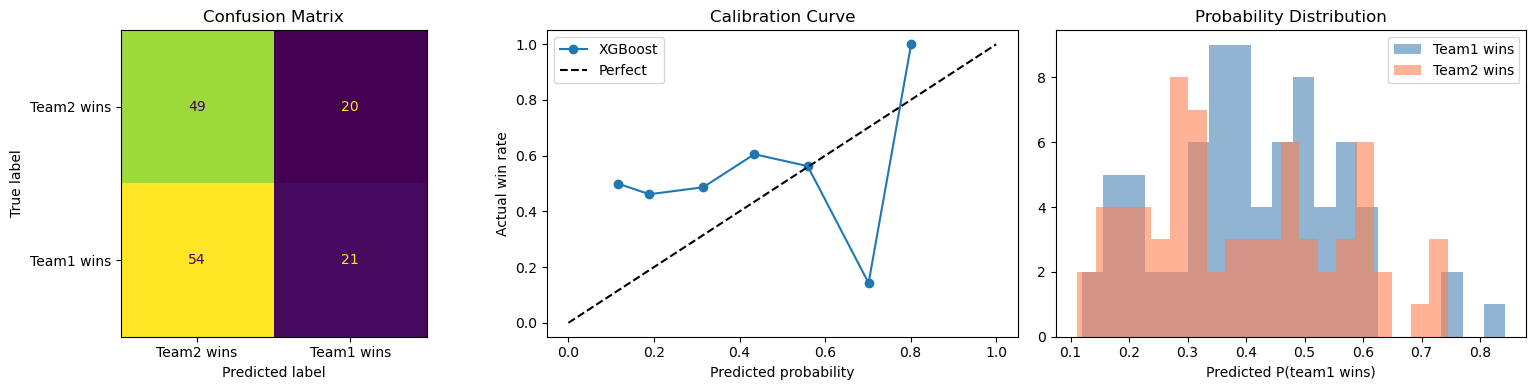

Saved → prematch_evaluation.png

Step 4 — SHAP explainability


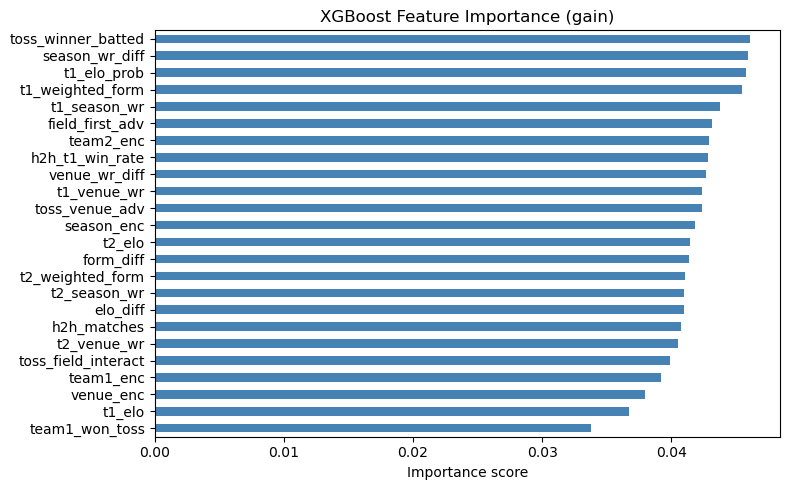

Saved → prematch_feature_importance.png


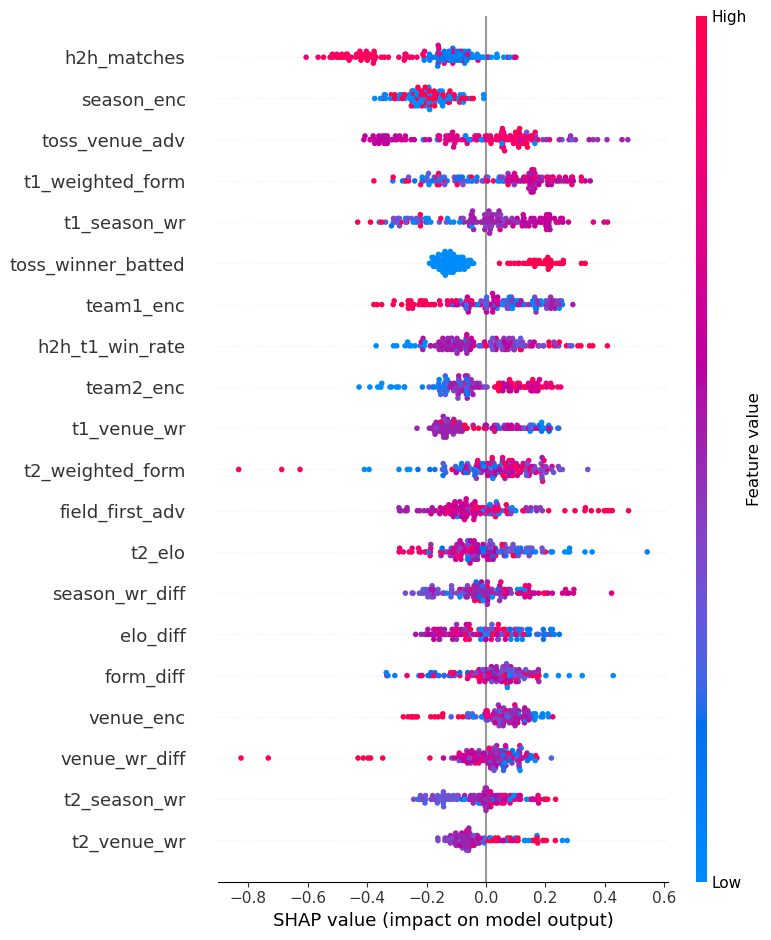

Saved → prematch_shap_summary.png


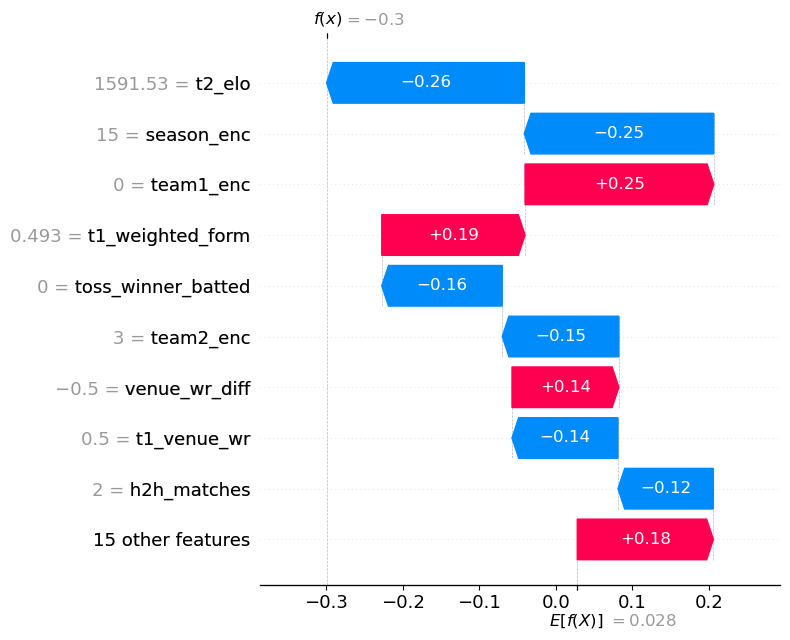

Saved → prematch_shap_waterfall.png

Step 5 — Saving model
Saved → prematch_model.pkl

✓ Done!
  Test accuracy : 0.4861
  Test log-loss : 0.7686
  Artifacts saved: prematch_model.pkl, prematch_evaluation.png,
                   prematch_feature_importance.png, prematch_shap_summary.png


In [22]:
"""
IPL Win Predictor — Pre-Match XGBoost Model
============================================
Input:  prematch_features.csv  (output of ipl_feature_engineering.py)
Output: prematch_model.pkl     (trained XGBoost model + encoders)

Sections:
  1. Load & split (time-based — no leakage)
  2. Train XGBoost with cross-validation
  3. Evaluate (accuracy, log-loss, calibration)
  4. SHAP explainability
  5. Save model
  6. Predict function (used by Streamlit app)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, log_loss,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
import shap


# ─────────────────────────────────────────────
# 1. LOAD & TIME-BASED TRAIN/TEST SPLIT
# ─────────────────────────────────────────────

FEATURES = [
    # Elo — strongest signal
    "t1_elo", "t2_elo", "elo_diff", "t1_elo_prob",
    # Form
    "t1_weighted_form", "t2_weighted_form", "form_diff",
    # Season form
    "t1_season_wr", "t2_season_wr", "season_wr_diff",
    # Venue
    "t1_venue_wr", "t2_venue_wr", "venue_wr_diff",
    "toss_venue_adv", "field_first_adv", "toss_field_interact",
    # H2H
    "h2h_t1_win_rate", "h2h_matches",
    # Toss
    "team1_won_toss", "toss_winner_batted",
    # Identity (encoded)
    "team1_enc", "team2_enc", "venue_enc", "season_enc",
]
TARGET = "team1_won"

def load_and_split(path="prematch_features.csv", test_seasons=2):
    df = pd.read_csv(path)

    # Robust date parsing — handles any format in the CSV
    df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
    n_bad = df["date"].isna().sum()
    if n_bad > 0:
        print(f"  Warning: {n_bad} rows had unparseable dates and were dropped")
    df = df.dropna(subset=["date"])
    df = df.sort_values("date").reset_index(drop=True)

    print(f"  Date range: {df['date'].min().date()} → {df['date'].max().date()}")
    print(f"  Total rows: {len(df)}")

    # Time-based split: last `test_seasons` IPL seasons as test set
    # Never use random split — that leaks future match history into training
    seasons = sorted(df["date"].dt.year.unique())
    print(f"  Seasons found: {seasons}")

    if len(seasons) < test_seasons + 1:
        raise ValueError(f"Not enough seasons ({len(seasons)}) to hold out {test_seasons}. Reduce test_seasons.")

    cutoff_year = seasons[-test_seasons]

    train = df[df["date"].dt.year < cutoff_year]
    test  = df[df["date"].dt.year >= cutoff_year]

    X_train = train[FEATURES]
    y_train = train[TARGET]
    X_test  = test[FEATURES]
    y_test  = test[TARGET]

    print(f"Train: {len(train)} matches ({seasons[0]}–{cutoff_year-1})")
    print(f"Test : {len(test)} matches ({cutoff_year}–{seasons[-1]})")
    print(f"Target balance (train): {y_train.mean():.3f} team1 win rate")

    return X_train, y_train, X_test, y_test, train, test


# ─────────────────────────────────────────────
# 2. TRAIN XGBOOST
# ─────────────────────────────────────────────

def train_model(X_train, y_train):
    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,               # shallow trees — avoids overfitting on ~700 rows
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,        # prevents splits on very small groups
        gamma=1.0,                 # minimum loss reduction for a split
        reg_alpha=0.1,             # L1 regularization
        reg_lambda=1.0,            # L2 regularization
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
    )

    # 5-fold stratified CV on training set
    cv = StratifiedKFold(n_splits=5, shuffle=False)  # shuffle=False preserves time order within folds
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    print(f"\nCV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"CV per fold: {[round(s, 4) for s in cv_scores]}")

    # Final fit on full training data
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train)],
        verbose=False,
    )

    print(f"\nModel trained — {model.n_estimators} trees, max_depth={model.max_depth}")
    return model


# ─────────────────────────────────────────────
# 3. EVALUATE
# ─────────────────────────────────────────────

def evaluate(model, X_test, y_test):
    y_pred      = model.predict(X_test)
    y_prob      = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    ll   = log_loss(y_test, y_prob)

    print("\n── Test Set Results ──")
    print(f"Accuracy : {acc:.4f}")
    print(f"Log-Loss : {ll:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["Team2 wins", "Team1 wins"]))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Team2 wins", "Team1 wins"],
        ax=axes[0], colorbar=False
    )
    axes[0].set_title("Confusion Matrix")

    # Calibration curve — is the model's 70% actually 70%?
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=8)
    axes[1].plot(prob_pred, prob_true, marker="o", label="XGBoost")
    axes[1].plot([0, 1], [0, 1], "k--", label="Perfect")
    axes[1].set_xlabel("Predicted probability")
    axes[1].set_ylabel("Actual win rate")
    axes[1].set_title("Calibration Curve")
    axes[1].legend()

    # Predicted probability distribution
    axes[2].hist(y_prob[y_test == 1], bins=20, alpha=0.6, label="Team1 wins", color="steelblue")
    axes[2].hist(y_prob[y_test == 0], bins=20, alpha=0.6, label="Team2 wins", color="coral")
    axes[2].set_xlabel("Predicted P(team1 wins)")
    axes[2].set_title("Probability Distribution")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig("prematch_evaluation.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → prematch_evaluation.png")

    return acc, ll


# ─────────────────────────────────────────────
# 4. FEATURE IMPORTANCE + SHAP
# ─────────────────────────────────────────────

def explain_model(model, X_train, X_test):
    # Built-in XGBoost feature importance
    fig, ax = plt.subplots(figsize=(8, 5))
    importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    importance.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title("XGBoost Feature Importance (gain)")
    ax.set_xlabel("Importance score")
    plt.tight_layout()
    plt.savefig("prematch_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → prematch_feature_importance.png")

    # SHAP — explains WHY each prediction was made
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    # Summary plot: which features matter most overall
    plt.figure()
    shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
    plt.tight_layout()
    plt.savefig("prematch_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → prematch_shap_summary.png")

    # Waterfall for a single match — explains one prediction in detail
    idx = 0  # change to any test row index
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_test.iloc[idx],
            feature_names=FEATURES,
        ),
        show=False
    )
    plt.tight_layout()
    plt.savefig("prematch_shap_waterfall.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → prematch_shap_waterfall.png")

    return explainer, shap_values


# ─────────────────────────────────────────────
# 5. SAVE MODEL
# ─────────────────────────────────────────────

def save_model(model, explainer, path="prematch_model.pkl"):
    payload = {
        "model"     : model,
        "explainer" : explainer,
        "features"  : FEATURES,
    }
    with open(path, "wb") as f:
        pickle.dump(payload, f)
    print(f"Saved → {path}")


# ─────────────────────────────────────────────
# 6. PREDICT FUNCTION (for Streamlit app)
# ─────────────────────────────────────────────

def load_model(path="prematch_model.pkl"):
    with open(path, "rb") as f:
        return pickle.load(f)


def predict_prematch(
    payload: dict,
    model_path="prematch_model.pkl"
) -> dict:
    """
    Given pre-match info, return win probabilities.

    payload keys must match FEATURES exactly. Example:
        {
            "team1_enc": 3,
            "team2_enc": 7,
            "venue_enc": 12,
            "season_enc": 11,
            "team1_won_toss": 1,
            "toss_winner_batted": 0,
            "t1_win_rate": 0.54,
            "t2_win_rate": 0.48,
            "h2h_t1_win_rate": 0.60,
            "h2h_matches": 15,
            "t1_venue_wr": 0.62,
            "t2_venue_wr": 0.41,
            "toss_venue_adv": 0.55,
            "t1_recent_form": 0.80,
            "t2_recent_form": 0.40,
        }

    Returns:
        {
            "team1_win_prob": 0.73,
            "team2_win_prob": 0.27,
            "shap_values": [...],
        }
    """
    bundle = load_model(model_path)
    model, explainer, features = bundle["model"], bundle["explainer"], bundle["features"]

    X = pd.DataFrame([payload])[features]
    prob = model.predict_proba(X)[0]
    shap_vals = explainer.shap_values(X)[0]

    return {
        "team1_win_prob": round(float(prob[1]), 4),
        "team2_win_prob": round(float(prob[0]), 4),
        "shap_values"   : shap_vals.tolist(),
        "feature_names" : features,
    }


# ─────────────────────────────────────────────
# 7. MAIN
# ─────────────────────────────────────────────

if __name__ == "__main__":
    print("=" * 55)
    print("IPL Pre-Match Win Predictor — XGBoost")
    print("=" * 55)

    print("\nStep 1 — Loading data and splitting by season")
    X_train, y_train, X_test, y_test, train, test = load_and_split(
        path="prematch_features.csv",
        test_seasons=2          # test on last 2 IPL seasons
    )

    print("\nStep 2 — Training XGBoost")
    model = train_model(X_train, y_train)

    print("\nStep 3 — Evaluating on test set")
    acc, ll = evaluate(model, X_test, y_test)

    print("\nStep 4 — SHAP explainability")
    explainer, shap_values = explain_model(model, X_train, X_test)

    print("\nStep 5 — Saving model")
    save_model(model, explainer)

    print("\n✓ Done!")
    print(f"  Test accuracy : {acc:.4f}")
    print(f"  Test log-loss : {ll:.4f}")
    print("  Artifacts saved: prematch_model.pkl, prematch_evaluation.png,")
    print("                   prematch_feature_importance.png, prematch_shap_summary.png")

In [23]:
import pandas as pd
df = pd.read_csv("prematch_features.csv")
print(df.groupby("season_enc")[["team1_won", "elo_diff"]].agg({"team1_won": "count", "elo_diff": "mean"}).rename(columns={"team1_won": "matches"}))

            matches   elo_diff
season_enc                    
0                58  -7.146379
1                56 -24.541429
2                59  -3.085254
3                72   5.236111
4                74  -0.566351
5                74  -3.207973
6                59   8.624576
7                56  -0.751964
8                60  -2.046167
9                58   3.714483
10               60  -4.939667
11               57  -8.688246
12               56  -0.550714
13               59   6.681695
14               74   2.692973
15               73  -5.369452
16               71   2.391408


In [24]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import pandas as pd

df = pd.read_csv("prematch_features.csv")

FEATURES = [
    "t1_elo", "t2_elo", "elo_diff", "t1_elo_prob",
    "t1_weighted_form", "t2_weighted_form", "form_diff",
    "t1_season_wr", "t2_season_wr", "season_wr_diff",
    "t1_venue_wr", "t2_venue_wr", "venue_wr_diff",
    "toss_venue_adv", "field_first_adv", "toss_field_interact",
    "h2h_t1_win_rate", "h2h_matches",
    "team1_won_toss", "toss_winner_batted",
    "team1_enc", "team2_enc", "venue_enc", "season_enc",
]

X = df[FEATURES]
y = df["team1_won"]

model = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                      random_state=42, eval_metric="logloss")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
print(f"Shuffled CV: {scores.mean():.4f} ± {scores.std():.4f}")
print(f"Per fold: {[round(s,4) for s in scores]}")

Shuffled CV: 0.5139 ± 0.0309
Per fold: [np.float64(0.5139), np.float64(0.4698), np.float64(0.5349), np.float64(0.493), np.float64(0.5581)]
